In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [ ]:
df.shape

(5268, 13)

In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
df.isna().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


Time: Leave the missing values as Unknown because the actuall crash time cannot be guessd correctly
Location: replace missing values with "Unknown" to retain the crash record without having to invent a crash location
Operator:Replace missing values with Unkown beacuse the airline or operator cannot be inferred
Flight: replace missing values with "Unkown" because flight numbers are identifiers and should not be estimated
Route: Replace missing values with "Unkown" because the route cannot be assumed
Type: replace missing values with Unkown to avaoid assigning incorrect aircraft type
Registration: Replace missing values with unkown because it cannot be estimated
cn/ln: Replace with Unkown because it identifies aircrafts and cannot be guessed
Abroad: Retain the missing values and exclude those records only from calculations requiring the number abroad and using zero or an average would introduce unsuppoerted passaanger counts
Fatalities:Retain missing values and exclude those records only from calculations requiring fatality counts zero would incorrectly imply that nobody died
Ground:Retain missing values and exclude those records only from calculations requiring ground fatality counts a missing value does not mean zero deaths.
summary:Replace missing values with No summary avaliable because crash description cannot be reliably invented.

In [ ]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
highest = fatality_locations['Fatalities'].idxmax()

fatality_locations.loc[highest, ['Date', 'Fatalities']]

,2963
Date,03/27/1977
Fatalities,583.0


In [ ]:
comparison = fatality_locations[['Aboard', 'Fatalities']].copy()
comparison['Survivors'] = comparison['Aboard'] -comparison['Fatalities']

display(comparison)
no_fatalities = (fatality_locations['Fatalities'] == 0).sum()
print("Crashes with no record onboard fatalities", no_fatalities)

,Aboard,Fatalities,Survivors
0,2.0,1.0,1.0
1,5.0,5.0,0.0
2,1.0,1.0,0.0
3,20.0,14.0,6.0
4,30.0,30.0,0.0
...,...,...,...
5263,112.0,98.0,14.0
5264,4.0,4.0,0.0
5265,228.0,228.0,0.0
5266,1.0,1.0,0.0


Crashes with no record onboard fatalities 58


In [ ]:
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location'].str.rsplit(',', n=1, expand=True)
)
fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State/Country'] = fatality_locations['State/Country'].str.strip()
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [ ]:
top_100 = fatality_locations.sort_values(
     by='Fatalities', ascending=False
).head(100)
top_100

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [ ]:
top_100 = fatality_locations.sort_values(
    by='Fatalities', ascending=False
).head(100)

top_100

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [ ]:
top_100 = top_100.copy()

top_100['State/Country'] = top_100['State/Country'].replace({
    'Canary Islands': 'Spain',
    'Scotland': 'United Kingdom',
    'Domincan Republic': 'Dominican Republic',
    'Surinam': 'Suriname',
    '110 miles West of Ireland': pd.NA,
    'Indian Ocean': pd.NA,
    'Antarctica': pd.NA
})

top_25 = (
    top_100.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

top_25

,Fatalities
State/Country,
Spain,1367.0
Japan,1209.0
USSR,850.0
Russia,846.0
Iran,826.0
Saudi Arabia,718.0
Brazil,706.0
France,656.0
New York,618.0


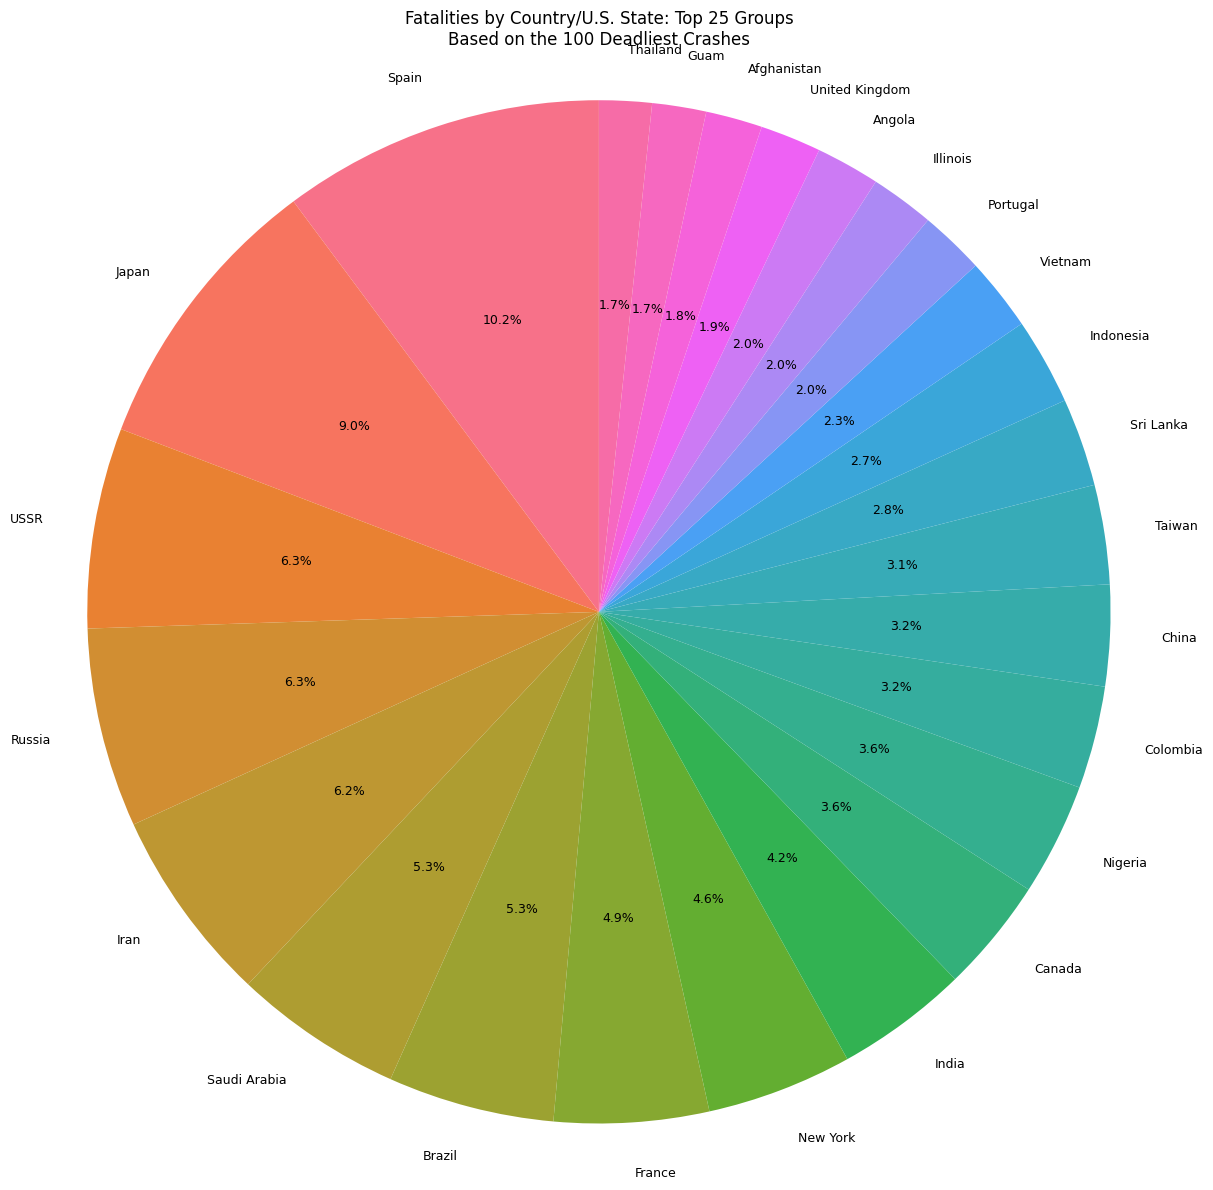

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))

plt.pie(
    top_25,
    labels=top_25.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('husl', len(top_25)),
    textprops={'fontsize': 9}
)

plt.title(
    'Fatalities by Country/U.S. State: Top 25 Groups\n'
    'Based on the 100 Deadliest Crashes'
)
plt.axis('equal')
plt.tight_layout()
plt.show()